In [ ]:
#Carga y análisis exploratorio 

import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#Creamos la conexión a la base de datos con la ruta del archivo .db
conn = sqlite3.connect("data/Northwind.db")

In [14]:

# 2. Creamos una consulta maestra con JOINs 
query_ventas = """
SELECT 
    o.OrderDate,
    c.CustomerName,
    c.Country,
    e.FirstName || ' ' || e.LastName AS Empleado,
    p.ProductName,
    cat.CategoryName,
    od.Quantity,
    p.Price,
    (od.Quantity * p.Price) AS IngresoLinea
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN Employees e ON o.EmployeeID = e.EmployeeID
JOIN OrderDetails od ON o.OrderID = od.OrderID
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
"""

# 3. Cargar en DataFrame
df_ventas = pd.read_sql_query(query_ventas, conn)


# 4. Análisis Exploratorio
print("--- Dimensiones ---")
print(df_ventas.shape) # (filas, columnas)


#Queremos saber la cantidad de valores nulos en cada columna del DataFrame. 
#Esto nos ayudará a identificar si hay datos faltantes que podrían afectar nuestro análisis.
print("\n--- Valores Nulos ---")
print(df_ventas.isnull().sum())

print("\n--- Producto más caro y más barato ---")
print(df_ventas.loc[df_ventas['Price'].idxmax(), ['ProductName', 'Price']])
print(df_ventas.loc[df_ventas['Price'].idxmin(), ['ProductName', 'Price']])

print("\n--- Primeras 5 filas por fecha ---")
df_ventas['OrderDate'] = pd.to_datetime(df_ventas['OrderDate']) # Convertir a fecha real
display(df_ventas.sort_values('OrderDate').head(5))

--- Dimensiones ---
(518, 9)

--- Valores Nulos ---
OrderDate       0
CustomerName    0
Country         0
Empleado        0
ProductName     0
CategoryName    0
Quantity        0
Price           0
IngresoLinea    0
dtype: int64

--- Producto más caro y más barato ---
ProductName    Côte de Blaye
Price                  263.5
Name: 218, dtype: object
ProductName    Geitost
Price              2.5
Name: 12, dtype: object

--- Primeras 5 filas por fecha ---


,OrderDate,CustomerName,Country,Empleado,ProductName,CategoryName,Quantity,Price,IngresoLinea
0,1996-07-04,Wilman Kala,Finland,Steven Buchanan,Queso Cabrales,Dairy Products,12,21.00,252.00
1,1996-07-04,Wilman Kala,Finland,Steven Buchanan,Singaporean Hokkien Fried Mee,Grains/Cereals,10,14.00,140.00
2,1996-07-04,Wilman Kala,Finland,Steven Buchanan,Mozzarella di Giovanni,Dairy Products,5,34.80,174.00
3,1996-07-05,Tradição Hipermercados,Brazil,Michael Suyama,Tofu,Produce,9,23.25,209.25
4,1996-07-05,Tradição Hipermercados,Brazil,Michael Suyama,Manjimup Dried Apples,Produce,40,53.00,2120.00


C:\Users\pabue\AppData\Local\Temp\ipykernel_28844\1390810517.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_productos, x='IngresoLinea', y='ProductName', palette='viridis')


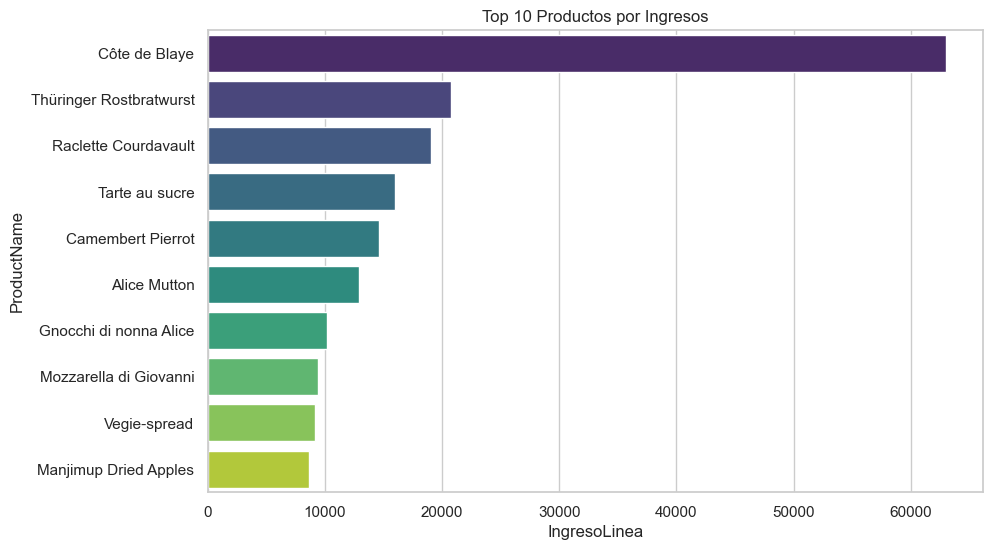

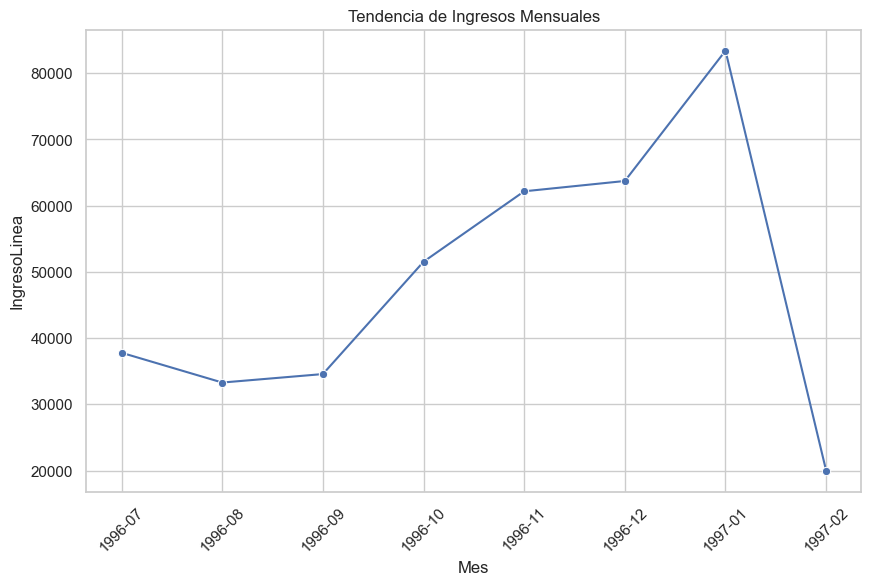

In [17]:

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Top 10 productos por ingresos
top_productos = df_ventas.groupby('ProductName')['IngresoLinea'].sum().nlargest(10).reset_index()
sns.barplot(data=top_productos, x='IngresoLinea', y='ProductName', palette='viridis')
plt.title('Top 10 Productos por Ingresos')
plt.show()

# 2. Evolución mensual
df_ventas['Mes'] = df_ventas['OrderDate'].dt.to_period('M') # Extrae Año-Mes
ventas_mensuales = df_ventas    .groupby('Mes')['IngresoLinea'].sum().reset_index()
ventas_mensuales['Mes'] = ventas_mensuales['Mes'].astype(str) # Para que matplotlib lo lea bien

sns.lineplot(data=ventas_mensuales, x='Mes', y='IngresoLinea', marker='o')
plt.xticks(rotation=45)
plt.title('Tendencia de Ingresos Mensuales')
plt.show()





In [20]:

# Aseguramos que la fecha sea tipo datetime
df_ventas['OrderDate'] = pd.to_datetime(df_ventas['OrderDate'])

# 1. Definir el "Mes de la Cohorte" (Primer mes de compra de cada cliente)
# Usamos CustomerID para ser precisos, y transform('min') para pegar esa fecha mínima a cada fila del cliente
df_ventas['CohortMonth'] = df_ventas.groupby('CustomerID')['OrderDate'].transform('min').dt.to_period('M')

# 2. Definir el "Mes de la Transacción" (El mes en que ocurrió esta compra específica)
df_ventas['TransactionMonth'] = df_ventas['OrderDate'].dt.to_period('M')

# 3. Calcular el "Índice de la Cohorte" (Diferencia en meses)
# Restamos el mes de la transacción menos el mes de la cohorte. 
# .apply(lambda x: x.n) convierte el resultado (ej. "2 meses") en un número entero (2)
df_ventas['CohortIndex'] = (df_ventas['TransactionMonth'] - df_ventas['CohortMonth']).apply(lambda x: x.n)

print("✅ Datos de cohorte calculados correctamente.")
print(f"Rango de meses analizados: {df_ventas['CohortMonth'].min()} a {df_ventas['CohortMonth'].max()}")

# Agrupamos por Cohorte (fila) e Índice de Mes (columna), sumando los ingresos
cohort_data = df_ventas.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='IngresoLinea',
    aggfunc='sum',
    fill_value=0
)

# Opcional: Redondear a 2 decimales para que se vea limpio
cohort_data = cohort_data.round(2)

print("📊 Tabla de Cohortes (Ingresos Totales):")
display(cohort_data.head())

# Configuración del gráfico
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

# Creamos el heatmap
# annot=True muestra los números, fmt='.0f' quita los decimales para mayor limpieza
# cmap='Blues' usa una escala de azules (más oscuro = más dinero)
ax = sns.heatmap(
    cohort_data, 
    annot=True, 
    fmt='.0f', 
    cmap='Blues', 
    linewidths=0.5,
    cbar_kws={'label': 'Ingresos Totales ($)'}
)

plt.title('🔥 Análisis de Cohortes: Ingresos por Mes desde la Primera Compra', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Meses transcurridos desde la primera compra (0 = Mes de inicio)', fontsize=12)
plt.ylabel('Cohorte (Mes de la primera compra del cliente)', fontsize=12)

# Ajustes estéticos
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Contamos clientes únicos (nunique) en lugar de sumar ingresos
retencion_data = df_ventas.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID',
    aggfunc='nunique',
    fill_value=0
)

# Calculamos el porcentaje dividiendo cada mes por el total inicial de la cohorte (Índice 0)
cohort_sizes = retencion_data.iloc[:, 0] # El tamaño inicial de cada cohorte
retencion_percentage = retencion_data.divide(cohort_sizes, axis=0) * 100

# Graficamos el porcentaje
plt.figure(figsize=(14, 8))
sns.heatmap(retencion_percentage, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100)
plt.title('🔄 Tasa de Retención de Clientes (%)', fontsize=16, fontweight='bold')
plt.show()

KeyError: 'CustomerID'

In [16]:
#Cerramos la conexión a la base de datos
conn.close()
